# Entrenamiento de YOLOv8 para Frutas (Detección + Clasificación)

Este notebook prepara automáticamente el dataset que descargaste en la carpeta `Fruits` y lanza el entrenamiento de un modelo YOLOv8 unificado.

## 1. Instalación de dependencias
Asegúrate de tener instalada la librería de ultralytics.

In [2]:
%pip install ultralytics PyYAML

## 2. Generación automática del archivo `data.yaml`
YOLO requiere un archivo YAML con las rutas absolutas a las imágenes y los nombres de las clases. Este script lo genera leyendo tu archivo `classes.txt`.

In [3]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [9]:
import os
import yaml
from pathlib import Path

# Rutas absolutas a tu dataset
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "drive" /"MyDrive"/"Fruits"

classes_file = DATASET_DIR / "labels" / "train" / "classes.txt"

if not classes_file.exists():
    print(f"Error: No se encontró el archivo {classes_file}")
else:
    # Leer clases
    with open(classes_file, 'r', encoding='utf-8') as f:
        classes = [line.strip() for line in f.readlines() if line.strip()]

    # Crear estructura del YAML
    data_yaml = {
        'path': str(DATASET_DIR.resolve()).replace('\\', '/'),
        'train': 'images/train',
        'val': 'images/val',
        'test': 'images/test',  # opcional
        'nc': len(classes),
        'names': classes
    }

    # Guardar data.yaml
    yaml_path = DATASET_DIR / "data.yaml"
    with open(yaml_path, 'w', encoding='utf-8') as f:
        yaml.dump(data_yaml, f, sort_keys=False)

    print(f"¡data.yaml generado exitosamente en {yaml_path}!")
    print(f"Clases encontradas ({len(classes)}): {classes}")

¡data.yaml generado exitosamente en /content/drive/MyDrive/Fruits/data.yaml!
Clases encontradas (15): ['cucumber', 'apple', 'kiwi', 'banana', 'orange', 'coconut', 'peach', 'cherry', 'pear', 'pomegranate', 'pineapple', 'watermelon', 'melon', 'grape', 'strawberry']


### División de datos 80-20 (Entrenamiento y Validación)

Este script lee las imágenes y etiquetas **originales de Drive** (solo lectura) y las copia en una carpeta **local de Colab** (`/content/dataset_split`). **Nunca se borran ni modifican los archivos originales de Drive.** El split 80/20 se aplica sobre todos los archivos encontrados en `images/train` y `labels/train`, generando:
- `80%` → `/content/dataset_split/images/train` y `labels/train`
- `20%` → `/content/dataset_split/images/val` y `labels/val` (también usado como test)

El `data.yaml` generado apunta a esta carpeta local, no a Drive.


In [10]:
import os
import yaml
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split
from collections import Counter

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURACIÓN
# DATASET_DIR apunta a los archivos ORIGINALES en Drive (solo lectura).
# SPLIT_DIR es la carpeta LOCAL de Colab donde se copia el split.
# Los archivos de Drive NUNCA se borran ni modifican.
# ─────────────────────────────────────────────────────────────────────────────
SPLIT_DIR = Path('/content/dataset_split')

# Carpetas fuente (Drive - solo lectura)
src_images_dir = DATASET_DIR / 'images' / 'train'
src_labels_dir = DATASET_DIR / 'labels' / 'train'

print(f"Fuente de imágenes (Drive, solo lectura): {src_images_dir}")
print(f"Fuente de etiquetas (Drive, solo lectura): {src_labels_dir}")
print(f"Destino del split (local Colab): {SPLIT_DIR}")

# Function to extract unique class IDs from a label file
def get_image_classes(label_path):
    classes_in_image = set()
    if label_path.is_file():
        with open(label_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    try:
                        class_id = int(parts[0])
                        classes_in_image.add(class_id)
                    except ValueError:
                        continue # Skip malformed lines
    return tuple(sorted(list(classes_in_image))) # Return sorted tuple for consistent stratification key

# ─── Recopilar pares imagen-etiqueta válidos Y sus combinaciones de clases ─
all_image_paths = []
all_label_paths = []
image_class_combinations = [] # This will be our 'y' for stratification

for ext in ['*.jpg', '*.jpeg', '*.png']:
    for img_path in sorted(src_images_dir.glob(ext)):
        label_path = src_labels_dir / f"{img_path.stem}.txt"
        if img_path.is_file() and label_path.is_file():
            classes_in_this_image = get_image_classes(label_path)
            if classes_in_this_image: # Only include images with valid labels
                all_image_paths.append(img_path)
                all_label_paths.append(label_path)
                image_class_combinations.append(classes_in_this_image)
            else:
                print(f"  ⚠ Sin clases válidas en {label_path.name} — se omite.")
        else:
            print(f"  ⚠ Sin par: {img_path.name} — se omite.")

if not all_image_paths:
    raise ValueError(
        f"No se encontraron pares imagen-etiqueta en:\n"
        f"  Imágenes: {src_images_dir}\n"
        f"  Etiquetas: {src_labels_dir}\n"
        "Verifica que la carpeta 'Fruits' esté correctamente montada en Drive."
    )

print(f"\nTotal de pares imagen-etiqueta encontrados: {len(all_image_paths)}")

# ─── Manejar combinaciones de clases raras para la estratificación ─────────
# train_test_split will fail if a stratum has fewer than 2 samples (for test_size=0.5)
# or fewer than `1 / test_size` samples in general.
# For test_size=0.2, need at least 1 / 0.2 = 5 samples per stratum to ensure both train and val get samples.
min_samples_per_stratum = int(1 / 0.2) + 1 # +1 to be safe, e.g., 5 samples for 80/20 split means 4 train, 1 val.
                                          # If min_samples_per_stratum is 5, and we need 1 for val, then 5 images are minimum.
                                          # If a stratum has 4 images, it cannot be split 80/20 while preserving proportion.

# Count occurrences of each class combination
combination_counts = Counter(image_class_combinations)

# Identify combinations that are too rare to stratify properly
rare_combinations = {k for k, v in combination_counts.items() if v < min_samples_per_stratum}

# Create a modified stratification key list
stratify_y = []
images_to_stratify = []
labels_to_stratify = []
images_to_add_randomly = []
labels_to_add_randomly = []

for i, combination in enumerate(image_class_combinations):
    if combination in rare_combinations:
        images_to_add_randomly.append(all_image_paths[i])
        labels_to_add_randomly.append(all_label_paths[i])
    else:
        images_to_stratify.append(all_image_paths[i])
        labels_to_stratify.append(all_label_paths[i])
        stratify_y.append(combination)

print(f"  Combinaciones de clases únicas: {len(combination_counts)}")
print(f"  Combinaciones de clases raras (agrupadas): {len(rare_combinations)} (menos de {min_samples_per_stratum} muestras)")
print(f"  Imágenes para estratificación: {len(images_to_stratify)}")
print(f"  Imágenes para añadir aleatoriamente: {len(images_to_add_randomly)}")

# ─── Split 80-20 (estratificado) ──────────────────────────────────────────
# Perform stratified split on the majority of images
if images_to_stratify:
    train_imgs_stratified, val_imgs_stratified, \
    train_lbls_stratified, val_lbls_stratified = train_test_split(
        images_to_stratify, labels_to_stratify,
        test_size=0.2, random_state=42, shuffle=True, stratify=stratify_y
    )
    # Combine with randomly added images to the training set (to avoid rare combinations in validation)
    train_imgs = train_imgs_stratified + images_to_add_randomly
    train_lbls = train_lbls_stratified + labels_to_add_randomly
    val_imgs = val_imgs_stratified
    val_lbls = val_lbls_stratified
    print("  Split estratificado realizado con éxito.")
else: # Fallback if no images can be stratified
    train_imgs, val_imgs, train_lbls, val_lbls = train_test_split(
        all_image_paths, all_label_paths,
        test_size=0.2, random_state=42, shuffle=True
    )
    print("  Advertencia: No se pudo realizar la estratificación debido a la escasez de muestras. Realizando split aleatorio.")

print(f"Set de entrenamiento (80%): {len(train_imgs)} imágenes")
print(f"Set de validación/prueba (20%): {len(val_imgs)} imágenes")

# ─── Crear carpetas destino LOCALES (Colab, no Drive) ─────────────────────
# Se limpian solo las carpetas locales del split anterior (si existen).
# Los archivos de Drive permanecen intactos.
dirs_to_create = {
    'train_img': SPLIT_DIR / 'images' / 'train',
    'train_lbl': SPLIT_DIR / 'labels' / 'train',
    'val_img':   SPLIT_DIR / 'images' / 'val',
    'val_lbl':   SPLIT_DIR / 'labels' / 'val',
    'test_img':  SPLIT_DIR / 'images' / 'test',
    'test_lbl':  SPLIT_DIR / 'labels' / 'test',
}

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)  # Limpia solo la carpeta local de Colab
    print(f"\nCarpeta local anterior eliminada: {SPLIT_DIR}")

for d in dirs_to_create.values():
    d.mkdir(parents=True, exist_ok=True)

# ─── Copiar archivos de entrenamiento ─────────────────────────────────────
print("\nCopiando set de entrenamiento (80%)...")
errores = 0
for img_src, lbl_src in zip(train_imgs, train_lbls):
    try:
        shutil.copy2(img_src, dirs_to_create['train_img'] / img_src.name)
        shutil.copy2(lbl_src, dirs_to_create['train_lbl'] / lbl_src.name)
    except Exception as e:
        print(f"  ⚠ Error copiando {img_src.name}: {e}")
        errores += 1
print(f"  ✓ {len(train_imgs) - errores} pares copiados al set de entrenamiento.")

# ─── Copiar archivos de validación/prueba ─────────────────────────────────
print("\nCopiando set de validación/prueba (20%)...")
errores = 0
for img_src, lbl_src in zip(val_imgs, val_lbls):
    try:
        shutil.copy2(img_src, dirs_to_create['val_img'] / img_src.name)
        shutil.copy2(lbl_src, dirs_to_create['val_lbl'] / lbl_src.name)
        # El set de test es igual al de val para evaluación final
        shutil.copy2(img_src, dirs_to_create['test_img'] / img_src.name)
        shutil.copy2(lbl_src, dirs_to_create['test_lbl'] / lbl_src.name)
    except Exception as e:
        print(f"  ⚠ Error copiando {img_src.name}: {e}")
        errores += 1
print(f"  ✓ {len(val_imgs) - errores} pares copiados al set de validación/prueba.")

# ─── Leer clases (desde Drive, que es la fuente de verdad) ────────────────
if 'classes' not in dir() or not classes:
    for candidate in [
        DATASET_DIR / 'labels' / 'train' / 'classes.txt',
        DATASET_DIR / 'classes.txt',
    ]:
        if candidate.exists():
            with open(candidate, 'r', encoding='utf-8') as f:
                classes = [l.strip() for l in f if l.strip()]
            print(f"\nClases cargadas desde: {candidate}")
            break
    else:
        raise FileNotFoundError(
            "No se encontró classes.txt en Drive. "
            "Verifica que exista en 'Fruits/labels/train/' o 'Fruits/'."
        )

# ─── Generar data.yaml apuntando al split LOCAL ───────────────────────────
# IMPORTANTE: el path apunta a SPLIT_DIR (local), NO a Drive.
data_yaml_content = {
    'path': str(SPLIT_DIR.resolve()),
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc':    len(classes),
    'names': classes,
}

yaml_path = SPLIT_DIR / 'data.yaml'
with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(data_yaml_content, f, sort_keys=False, allow_unicode=True)

# Guardamos la ruta para usarla en celdas posteriores
DATA_YAML_PATH = str(yaml_path)

print(f"\n✅ Split 80-20 completado.")
print(f"   data.yaml generado en: {yaml_path}")
print(f"   Clases ({len(classes)}): {classes}")
print(f"\nLos archivos originales de Drive en '{DATASET_DIR}' NO fueron modificados.")


Fuente de imágenes (Drive, solo lectura): /content/drive/MyDrive/Fruits/images/train
Fuente de etiquetas (Drive, solo lectura): /content/drive/MyDrive/Fruits/labels/train
Destino del split (local Colab): /content/dataset_split
  ⚠ Sin par: 242.jpg — se omite.
  ⚠ Sin par: 651.jpg — se omite.
  ⚠ Sin par: 652.jpg — se omite.
  ⚠ Sin par: 653.jpg — se omite.
  ⚠ Sin par: 654.jpg — se omite.
  ⚠ Sin par: 655.jpg — se omite.
  ⚠ Sin par: 656.jpg — se omite.
  ⚠ Sin par: 657.jpg — se omite.
  ⚠ Sin par: 659.jpg — se omite.
  ⚠ Sin par: 660.jpg — se omite.
  ⚠ Sin par: 661.jpg — se omite.
  ⚠ Sin par: 662.jpg — se omite.
  ⚠ Sin par: 663.jpg — se omite.
  ⚠ Sin par: 664.jpg — se omite.
  ⚠ Sin par: 665.jpg — se omite.
  ⚠ Sin par: 666.jpg — se omite.
  ⚠ Sin par: 667.jpg — se omite.
  ⚠ Sin par: 668.jpg — se omite.
  ⚠ Sin par: 669.jpg — se omite.
  ⚠ Sin par: 670.jpg — se omite.
  ⚠ Sin par: 671.jpg — se omite.
  ⚠ Sin par: 672.jpg — se omite.
  ⚠ Sin par: 673.jpg — se omite.
  ⚠ Sin par: 6

### Entrenamiento del Modelo YOLOv8 con el nuevo split

Ahora entrenaremos el modelo YOLOv8 utilizando el nuevo `data.yaml` que refleja el split 80-20. Empezaremos desde un modelo `yolov8n.pt` pre-entrenado para un nuevo ciclo de entrenamiento. Puedes ajustar los `epochs`, `imgsz` (tamaño de la imagen) o `batch` si lo consideras necesario.

In [11]:
from ultralytics import YOLO
import torch
from pathlib import Path

# DATA_YAML_PATH fue definido en la celda anterior (apunta al split local)
# Si reiniciaste el kernel, vuelve a ejecutar las celdas anteriores primero.
print(f"Usando data.yaml: {DATA_YAML_PATH}")

# Verificar GPU
device = 0 if torch.cuda.is_available() else 'cpu'
print(f"Entrenando usando: {'GPU' if device == 0 else 'CPU'}")

# Modelo base preentrenado
model = YOLO('yolov8n.pt')

print(f"Iniciando entrenamiento con split 80-20...")
results = model.train(
    data=DATA_YAML_PATH,
    epochs=50,
    imgsz=640,
    name='yolov8_fruits_80_20_split',
    device=device,
)

print("\nEntrenamiento completado. El modelo (best.pt) se guarda en la carpeta 'runs'.")


Usando data.yaml: /content/dataset_split/data.yaml
Entrenando usando: GPU
Iniciando entrenamiento con split 80-20...
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_split/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_s

### Evaluación del Modelo Re-entrenado

Una vez completado el entrenamiento, evaluaremos el rendimiento del modelo en el nuevo conjunto de prueba (el 20% de los datos originales) y obtendremos las métricas de precisión, recall y F1-score.

In [12]:
from ultralytics import YOLO
from pathlib import Path
import glob

# DATA_YAML_PATH fue definido en la celda de split (apunta al split local)
print(f"Usando data.yaml: {DATA_YAML_PATH}")

# Buscar el último run de entrenamiento con nombre específico
runs_base_dir = Path('runs') / 'detect'
training_run_dirs = sorted(glob.glob(str(runs_base_dir / 'yolov8_fruits_80_20_split*')))

if training_run_dirs:
    latest_training_run_dir = Path(training_run_dirs[-1])
    trained_model_path = latest_training_run_dir / 'weights' / 'best.pt'
    print(f"Última carpeta de entrenamiento encontrada: {latest_training_run_dir}")
else:
    trained_model_path = runs_base_dir / 'train' / 'weights' / 'best.pt'
    print(f"No se encontró run con nombre específico. Intentando: {trained_model_path}")

if trained_model_path.exists():
    model = YOLO(str(trained_model_path))
    print(f"Modelo cargado desde: {trained_model_path}")
else:
    print(f"⚠ No se encontró el modelo en {trained_model_path}.")
    print("Cargando modelo base 'yolov8n.pt' (los resultados no reflejarán el entrenamiento).")
    model = YOLO('yolov8n.pt')

# Evaluar en el set de test (el 20% del split local)
print(f"\nEvaluando modelo en el set de 'test' (20% del split)...")
metrics = model.val(data=DATA_YAML_PATH, split='test')

print(f"\nmAP50-95: {metrics.box.map:.3f}")
print(f"mAP50:    {metrics.box.map50:.3f}")
print("\nEvaluación completada.")

# Métricas por clase
names = metrics.names
precision = metrics.box.p
recall = metrics.box.r
f1_score = metrics.box.f1

print("\n--- Métricas por Clase ---")
for i, name in enumerate(names):
    print(f"Clase: {name}")
    print(f"  Precisión: {precision[i]:.3f}")
    print(f"  Recall:    {recall[i]:.3f}")
    print(f"  F1-Score:  {f1_score[i]:.3f}")
    print("  ─────────────────────")

print(f"\nOverall mAP50-95: {metrics.box.map:.3f}")
print(f"Overall mAP50:    {metrics.box.map50:.3f}")


Usando data.yaml: /content/dataset_split/data.yaml
Última carpeta de entrenamiento encontrada: runs/detect/yolov8_fruits_80_20_split-2
Modelo cargado desde: runs/detect/yolov8_fruits_80_20_split-2/weights/best.pt

Evaluando modelo en el set de 'test' (20% del split)...
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 904.3±1021.9 MB/s, size: 50.3 KB)
val: Scanning /content/dataset_split/labels/test... 212 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 212/212 1.9Kit/s 0.1s
val: New cache created: /content/dataset_split/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 2.9it/s 4.9s
                   all        212        534      0.912      0.882       0.93      0.757
              cucumber         14         41          1      0.768      

### Visualización de Resultados del Nuevo Entrenamiento

A continuación, mostramos los gráficos generados (Matriz de Confusión, Curva PR y F1-Score por Clase) basados en la evaluación del modelo re-entrenado en el nuevo conjunto de prueba.

Última carpeta de resultados de validación encontrada: runs/detect/val-2
Mostrando gráficos desde: runs/detect/val-2

--- Matriz de Confusión Normalizada (Nuevo Entrenamiento) ---


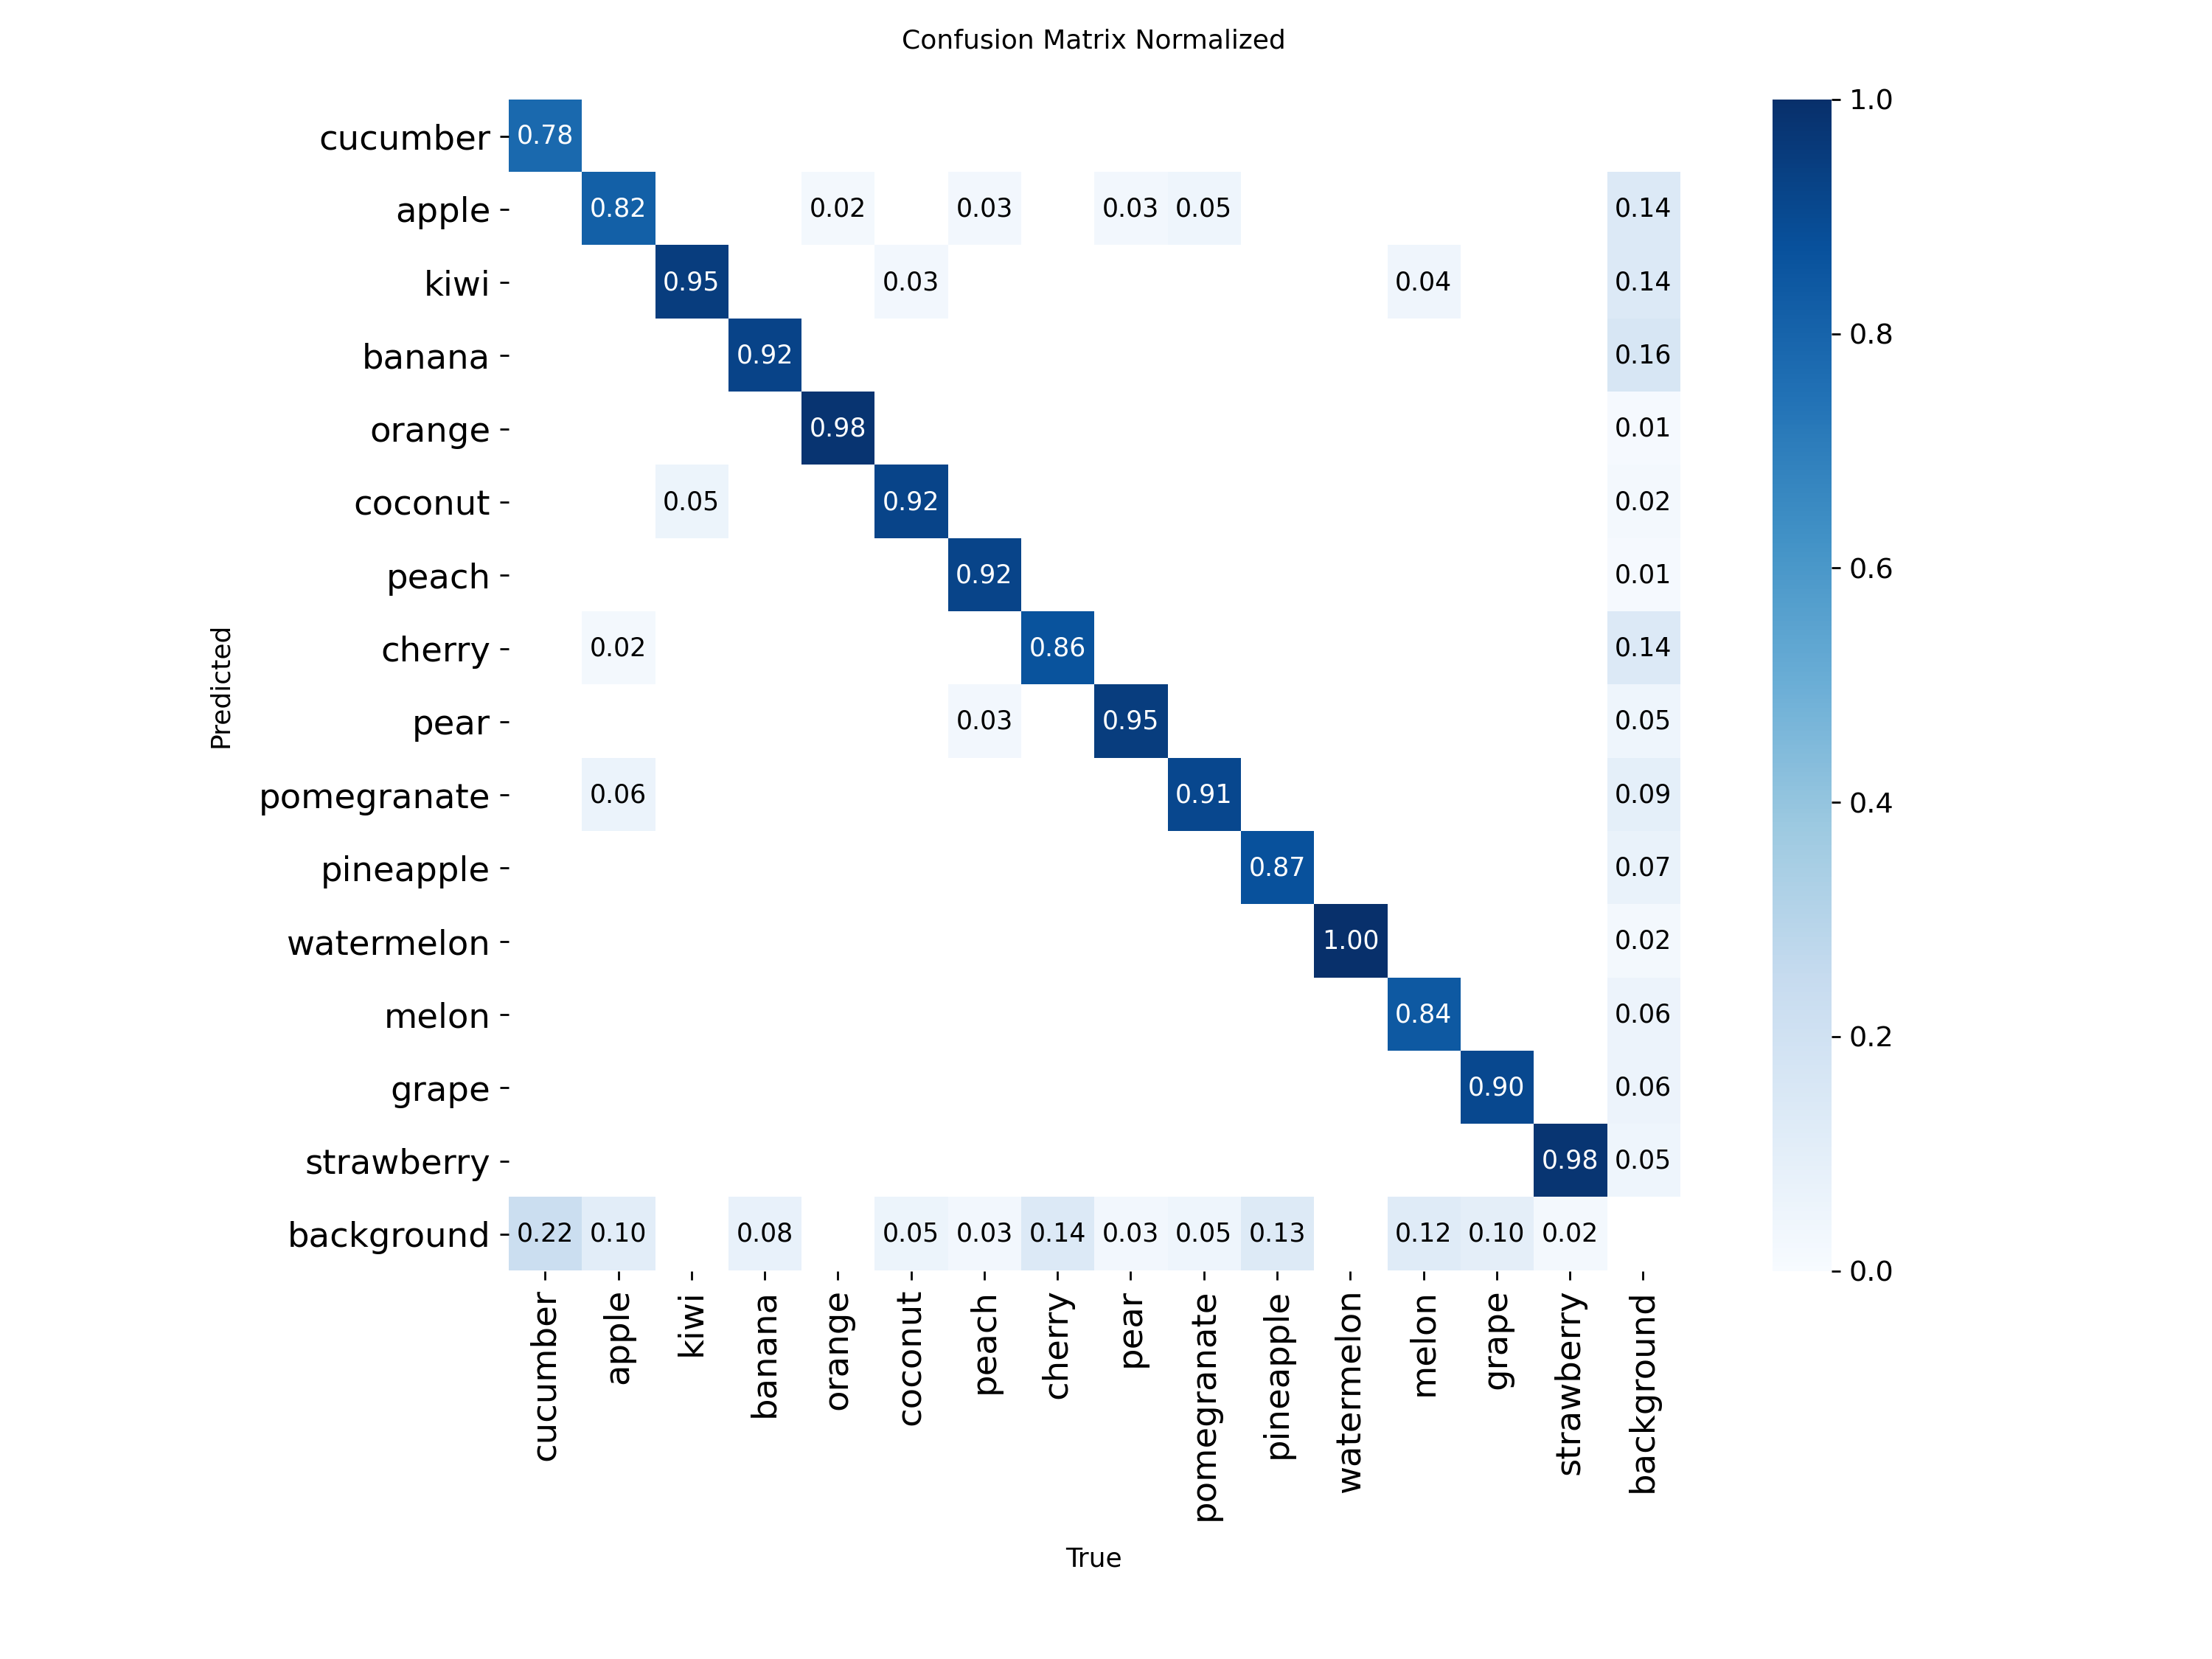

Advertencia: No se encontró la curva PR en runs/detect/val-2/PR_curve.png


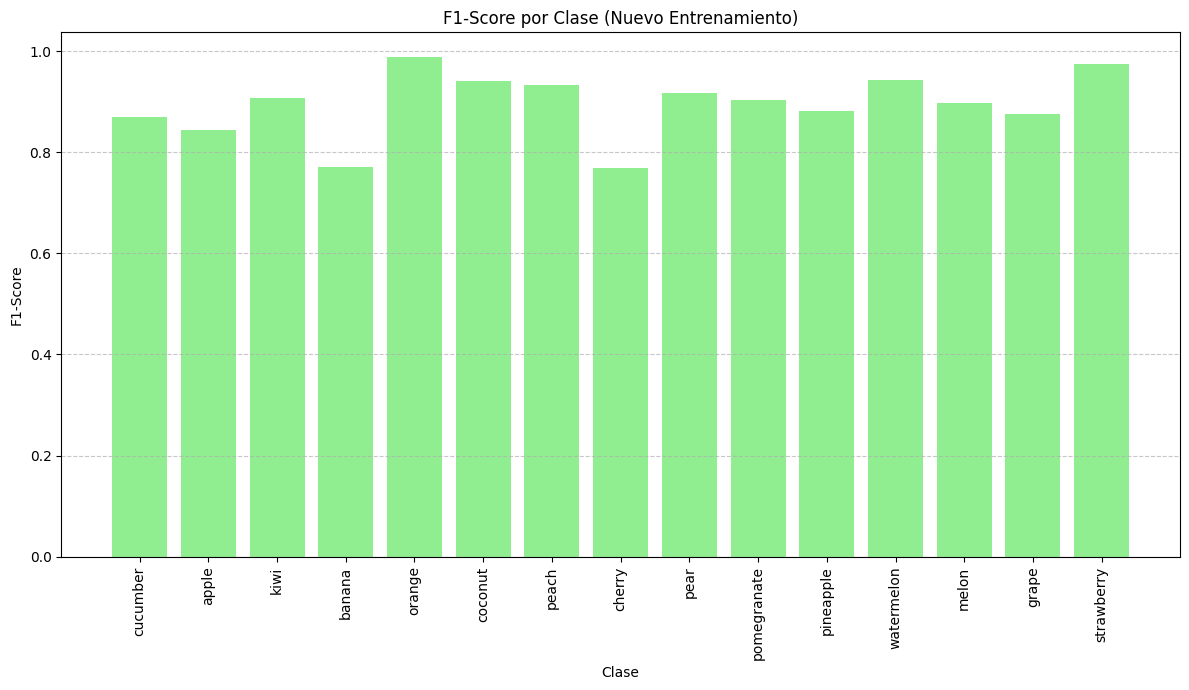

In [13]:
import matplotlib.pyplot as plt
from IPython.display import Image, display
from pathlib import Path
import glob
import numpy as np

# Dynamically find the latest validation run directory
# This will usually be a 'val' directory created by the last model.val() run
runs_val_dir = Path('runs') / 'detect'
# Look for directories that are results of validation runs, which usually start with 'val'
# and might have an incrementing number (e.g., 'val', 'val2', 'val3', etc.)
val_dirs_candidates = sorted(glob.glob(str(runs_val_dir / 'val*')))

latest_val_dir = None
if val_dirs_candidates:
    # Filter to ensure they are actual directories and get the latest one
    val_dirs = [d for d in val_dirs_candidates if Path(d).is_dir()]
    if val_dirs:
        latest_val_dir = Path(val_dirs[-1])
        print(f"Última carpeta de resultados de validación encontrada: {latest_val_dir}")

if latest_val_dir is None:
    print(f"No se encontró ninguna carpeta de validación. Intentando usar la predeterminada: {runs_val_dir / 'val'}")
    latest_val_dir = runs_val_dir / 'val' # Fallback to default if no other 'val' dirs found

results_dir = latest_val_dir # Set results_dir to the latest one

print(f"Mostrando gráficos desde: {results_dir}")

# Mostrar la Matriz de Confusión normalizada
confusion_matrix_path = results_dir / 'confusion_matrix_normalized.png'
if confusion_matrix_path.exists():
    print("\n--- Matriz de Confusión Normalizada (Nuevo Entrenamiento) ---")
    display(Image(filename=str(confusion_matrix_path)))
else:
    print(f"Advertencia: No se encontró la matriz de confusión normalizada en {confusion_matrix_path}")

# Mostrar la Curva Precision-Recall (PR Curve)
pr_curve_path = results_dir / 'PR_curve.png'
if pr_curve_path.exists():
    print("\n--- Curva Precision-Recall (P-R Curve) (Nuevo Entrenamiento) ---")
    display(Image(filename=str(pr_curve_path)))
else:
    print(f"Advertencia: No se encontró la curva PR en {pr_curve_path}")

# Display F1-Score per class again after new training
# Assuming 'names' and 'f1_score' are available from the previous cell's execution
if 'names' in locals() and 'f1_score' in locals() and names and len(f1_score) == len(names):
    class_names_list = [names[i] for i in range(len(names))]

    plt.figure(figsize=(12, 7))
    plt.bar(class_names_list, f1_score, color='lightgreen') # Using a different color for distinction
    plt.xlabel('Clase')
    plt.ylabel('F1-Score')
    plt.title('F1-Score por Clase (Nuevo Entrenamiento)')
    plt.xticks(rotation=90)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo se pudieron generar el gráfico de F1-Score por clase. Asegúrese de que las métricas de evaluación se hayan calculado en el paso anterior y que existan 'names' y 'f1_score'.")
